In [2]:
import torch
import torch.nn as nn
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
from model import LSTMClassifier
import pandas as pd

In [6]:
from dataWorker import getOHLC

# load all btc candles from 1'st Jan 2026

iters = 300

df = pd.DataFrame()
for i in range(iters):
    df_1000mins = getOHLC('BTCUSDT', (1767214800+60*i*1000)*1000, (1767214800+60*(i+1)*1000-60)*1000, normalize=False)
    df = pd.concat([df, df_1000mins], axis=0)
    print(f"{i+1}/{iters}", len(df))

# save to parquet
df.to_parquet('data/real/btcusdt_7months.parquet')

1/300 1000
2/300 2000
3/300 3000
4/300 4000
5/300 5000
6/300 6000
7/300 7000
8/300 8000
9/300 9000
10/300 10000
11/300 11000
12/300 12000
13/300 13000
14/300 14000
15/300 15000
16/300 16000
17/300 17000
18/300 18000
19/300 19000
20/300 20000
21/300 21000
22/300 22000
23/300 23000
24/300 24000
25/300 25000
26/300 26000
27/300 27000
28/300 28000
29/300 29000
30/300 30000
31/300 31000
32/300 32000
33/300 33000
34/300 34000
35/300 35000
36/300 36000
37/300 37000
38/300 38000
39/300 39000
40/300 40000
41/300 41000
42/300 42000
43/300 43000
44/300 44000
45/300 45000
46/300 46000
47/300 47000
48/300 48000
49/300 49000
50/300 50000
51/300 51000
52/300 52000
53/300 53000
54/300 54000
55/300 55000
56/300 56000
57/300 57000
58/300 58000
59/300 59000
60/300 60000
61/300 61000
62/300 62000
63/300 63000
64/300 64000
65/300 65000
66/300 66000
67/300 67000
68/300 68000
69/300 69000
70/300 70000
71/300 71000
72/300 72000
73/300 73000
74/300 74000
75/300 75000
76/300 76000
77/300 77000
78/300 78000
79/3

288854
timestamp
0 days 00:01:00    288853
Name: count, dtype: int64


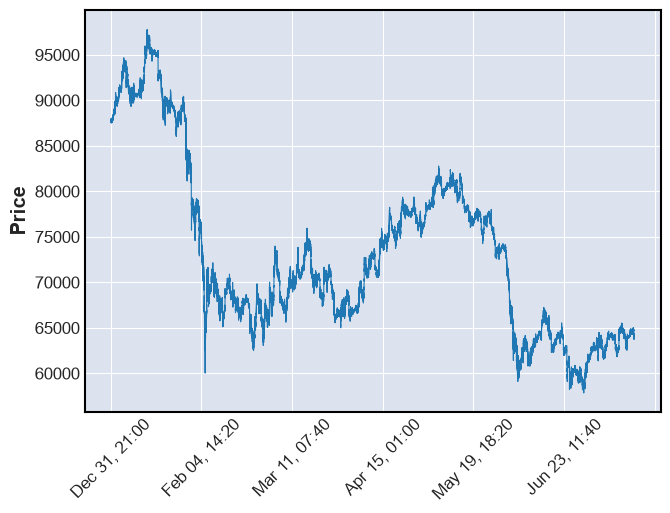

Loaded 3040 windows


In [28]:
# load from parquest
df = pd.read_parquet('data/real/btcusdt_bear_7months.parquet')

import mplfinance as mpl

df = df.set_index("timestamp")
# check for gaps in chart
print(len(df))
print(df.index.to_series().diff().value_counts())

#  plotting for debug
mpl.plot(df, type="line")


window_size = 95
input_size = 90

inputs_windows, result_windows = [], []
for i in range(0, len(df)-window_size+1, window_size):
    window = df.iloc[i:i+window_size]

    inputs_windows.append(window.iloc[:input_size])
    result_windows.append(window.iloc[input_size:])
    
print(f"Loaded {len(inputs_windows)} windows")

In [41]:
def predict(model, df, feature_cols, window=60, device="cpu"):
    """
    df: DataFrame с уже посчитанными фичами (те же, что при обучении!)
    Возвращает предсказание для ПОСЛЕДНЕГО окна в df
    """
    model.eval()
    model.to(device)
    
    features = df[feature_cols].values.astype(np.float32)
    
    if len(features) < window:
        raise ValueError(f"Недостаточно данных: нужно минимум {window} свечей, получено {len(features)}")
    
    x = features[-window:]  # last window
    
    if np.isnan(x).any() or np.isinf(x).any():
        raise ValueError(f"NaN/Inf в входных данных! NaN count: {np.isnan(x).sum()}, Inf count: {np.isinf(x).sum()}")
    
    x_tensor = torch.tensor(x).unsqueeze(0).to(device)  # batch dimension -> (1, window, n_features)
    
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = probs.argmax(dim=1).item()
    
    class_names = {0: "down", 1: "flat", 2: "up"}
    return {
        "prediction": class_names[pred_class],
        "probabilities": {
            "down": probs[0][0].item(),
            "flat": probs[0][1].item(),
            "up": probs[0][2].item()
        }
    }

In [42]:
import pandas as pd
from model import prepare_features_and_labels, feature_cols

# нужно заново создать модель с ТЕМИ ЖЕ параметрами архитектуры
model = LSTMClassifier(n_features=5, hidden_size=64, num_layers=2, num_classes=3)
model.load_state_dict(torch.load("models/lstm_1440_0046_23.pt", map_location="cpu"))
model.eval()  # важно! переключает dropout/batchnorm в режим инференса

LSTMClassifier(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [43]:
import random
intervals = []

for i in range(100):
    random_hour = random.randint(0,10000)
    start = ( 1784365200-60*60*random_hour-60*90 )*1000
    end = ( 1784365200-60*60*random_hour )*1000
    intervals.append([start, end])
 
print(intervals)  
intervals = [[1767443400000, 1767448800000], [1766665800000, 1766671200000], [1764365400000, 1764370800000], [1748554200000, 1748559600000], [1777069800000, 1777075200000], [1764484200000, 1764489600000], [1765765800000, 1765771200000], [1770834600000, 1770840000000], [1763649000000, 1763654400000], [1749357000000, 1749362400000], [1754073000000, 1754078400000], [1780180200000, 1780185600000], [1773451800000, 1773457200000], [1754526600000, 1754532000000], [1781191800000, 1781197200000], [1754530200000, 1754535600000], [1758047400000, 1758052800000], [1773358200000, 1773363600000], [1780158600000, 1780164000000], [1773876600000, 1773882000000], [1769092200000, 1769097600000], [1775169000000, 1775174400000], [1783985400000, 1783990800000], [1752571800000, 1752577200000], [1754879400000, 1754884800000], [1751002200000, 1751007600000], [1750419000000, 1750424400000], [1773088200000, 1773093600000], [1776983400000, 1776988800000], [1751916600000, 1751922000000], [1755999000000, 1756004400000], [1778034600000, 1778040000000], [1757320200000, 1757325600000], [1771597800000, 1771603200000], [1775615400000, 1775620800000], [1778704200000, 1778709600000], [1782102600000, 1782108000000], [1756153800000, 1756159200000], [1749594600000, 1749600000000], [1777998600000, 1778004000000], [1764732600000, 1764738000000], [1758015000000, 1758020400000], [1766133000000, 1766138400000], [1766356200000, 1766361600000], [1781476200000, 1781481600000], [1781595000000, 1781600400000], [1764084600000, 1764090000000], [1767331800000, 1767337200000], [1757802600000, 1757808000000], [1764444600000, 1764450000000], [1748388600000, 1748394000000], [1774125000000, 1774130400000], [1755934200000, 1755939600000], [1765103400000, 1765108800000], [1759368600000, 1759374000000], [1749231000000, 1749236400000], [1754159400000, 1754164800000], [1763670600000, 1763676000000], [1752341400000, 1752346800000], [1765499400000, 1765504800000], [1763386200000, 1763391600000], [1760178600000, 1760184000000], [1759091400000, 1759096800000], [1781580600000, 1781586000000], [1770298200000, 1770303600000], [1783783800000, 1783789200000], [1754731800000, 1754737200000], [1783636200000, 1783641600000], [1771270200000, 1771275600000], [1748964600000, 1748970000000], [1769157000000, 1769162400000], [1780612200000, 1780617600000], [1760941800000, 1760947200000], [1761982200000, 1761987600000], [1773012600000, 1773018000000], [1757953800000, 1757959200000], [1748773800000, 1748779200000], [1750278600000, 1750284000000], [1749540600000, 1749546000000], [1776493800000, 1776499200000], [1765909800000, 1765915200000], [1765935000000, 1765940400000], [1782307800000, 1782313200000], [1775475000000, 1775480400000], [1777757400000, 1777762800000], [1762943400000, 1762948800000], [1765513800000, 1765519200000], [1769542200000, 1769547600000], [1757143800000, 1757149200000], [1763224200000, 1763229600000], [1777350600000, 1777356000000], [1781573400000, 1781578800000], [1776263400000, 1776268800000], [1756884600000, 1756890000000], [1768523400000, 1768528800000], [1750055400000, 1750060800000], [1781512200000, 1781517600000], [1757849400000, 1757854800000], [1780817400000, 1780822800000], [1760275800000, 1760281200000]]

[[1766644200000, 1766649600000], [1755646200000, 1755651600000], [1764279000000, 1764284400000], [1768386600000, 1768392000000], [1768462200000, 1768467600000], [1761078600000, 1761084000000], [1766532600000, 1766538000000], [1771853400000, 1771858800000], [1780191000000, 1780196400000], [1770737400000, 1770742800000], [1754443800000, 1754449200000], [1750109400000, 1750114800000], [1780381800000, 1780387200000], [1774971000000, 1774976400000], [1782102600000, 1782108000000], [1752611400000, 1752616800000], [1762216200000, 1762221600000], [1778801400000, 1778806800000], [1752075000000, 1752080400000], [1760787000000, 1760792400000], [1781245800000, 1781251200000], [1777962600000, 1777968000000], [1748745000000, 1748750400000], [1768541400000, 1768546800000], [1757835000000, 1757840400000], [1758479400000, 1758484800000], [1760697000000, 1760702400000], [1777789800000, 1777795200000], [1782819000000, 1782824400000], [1756884600000, 1756890000000], [1779309000000, 1779314400000], [177495

loss, prediction down 0.9995711445808411, profit -20 points, ttl -20, winrate 0.0
loss, prediction down 0.9118567705154419, profit -20 points, ttl -40, winrate 0.0
loss, prediction down 0.9911942481994629, profit -20 points, ttl -60, winrate 0.0
win, prediction down 0.9998606443405151, profit 50 points, ttl -10, winrate 0.25
win, prediction up 0.6117396354675293, profit 50 points, ttl 40, winrate 0.4
win, prediction up 0.8857271075248718, profit 50 points, ttl 90, winrate 0.5
loss, prediction down 0.8865888714790344, profit -20 points, ttl 70, winrate 0.429
loss, prediction down 0.9953227639198303, profit -20 points, ttl 50, winrate 0.375
win, prediction up 0.9987082481384277, profit 50 points, ttl 100, winrate 0.444
loss, prediction down 0.9999254941940308, profit -20 points, ttl 80, winrate 0.4
win, prediction up 0.838263213634491, profit 50 points, ttl 130, winrate 0.455
win, prediction down 0.9994757771492004, profit 50 points, ttl 180, winrate 0.5
loss, prediction down 0.999997615

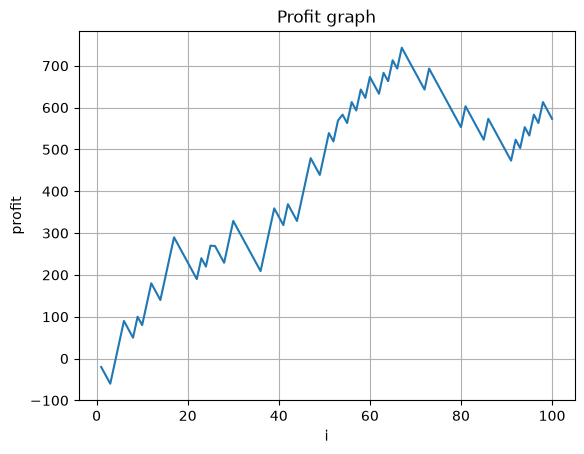

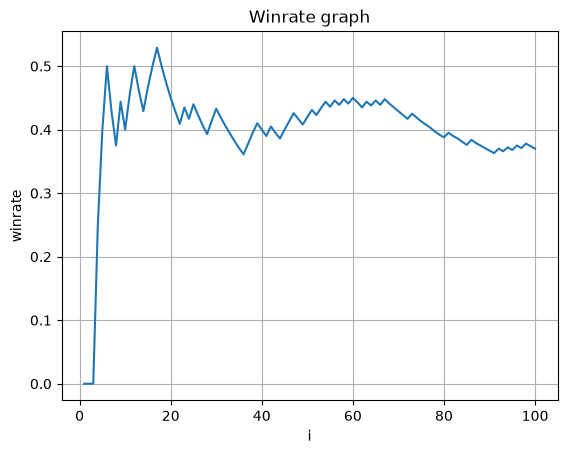

In [ ]:
from dataWorker import *
from datetime import datetime
from dataWorker import getOHLC
import matplotlib.pyplot as plt
# loading real data for test

profit_ttl = 0
wins = 0
profit_history = []
winrate_history = []
iters = 100
for i, interval in enumerate(intervals[:iters]):
    start = interval[0]
    end = interval[1]
    test_df = getOHLC('BTCUSDT', start, end, normalize=True)
    test_df = prepare_features_and_labels(test_df, horizon=5, flat_threshold=0.001) 
    #print(f"Selected interval from {datetime.fromtimestamp(start//1000)} to {datetime.fromtimestamp(end//1000)}")
    result = predict(model, test_df, feature_cols, window=5)
    #print(result)
    
    # collecting data from exchange
    df_plot = getOHLC('BTCUSDT', start, end)
    df_plot = df_plot.set_index("timestamp")
    df_final = getOHLC('BTCUSDT', (end//1000+60)*1000,(end//1000+60*5)*1000)
    df_final = df_final.set_index("timestamp")

    open_price = float(df_final.iloc[0]['open'])
    # check for stop-loss or take-profit
    take_profit = 50
    stop_loss = 20
    
    for j in range(5):
        if result.get('prediction') == 'up' : 
            if df_final.iloc[j]['high'] >= open_price + take_profit:
                profit = take_profit
                break
            if df_final.iloc[j]['low'] <= open_price - stop_loss:
                profit = stop_loss*-1
                break
        if result.get('prediction') == 'down' : 
            if df_final.iloc[j]['high'] >= open_price + stop_loss:
                profit = stop_loss*-1
                break
            if df_final.iloc[j]['low'] <= open_price - take_profit:
                profit = take_profit
                break
        else:
            profit = round(df_final.iloc[j]['close']  - open_price, 3)
    
    
    if profit>0: wins += 1
    profit_ttl += profit
    profit_ttl = round(profit_ttl, 2)
    print(f"{'win' if profit>0 else 'loss'}, prediction {result.get('prediction')} {result.get('probabilities').get(result.get('prediction'))}, profit {profit} points, ttl {profit_ttl}, winrate {round(wins/(i+1),3)}")
    
    profit_history.append(profit_ttl)
    winrate_history.append(round(wins/(i+1),3))
    
    
print(f"Profit: {profit_ttl} points with winrate {round(wins/iters,2)}")    

fig, ax = plt.subplots()
t = np.arange(1,iters+1, 1)
ax.plot(t, profit_history)
ax.set(xlabel='i', ylabel='profit',
       title='Profit graph')
ax.grid()
plt.show()

fig, ax = plt.subplots()
ax.plot(t, winrate_history)
ax.set(xlabel='i', ylabel='winrate',
       title='Winrate graph')
ax.grid()
plt.show()

In [45]:
# from dataWorker import getOHLC
# import mplfinance as mpf

# df_plot = getOHLC('BTCUSDT', start, end)
# df_plot = df_plot.set_index("timestamp")
# df_final = getOHLC('BTCUSDT', (end//1000+60)*1000,(end//1000+60*5)*1000)
# df_final = df_final.set_index("timestamp")

# open_price = float(df_final.iloc[0]['open'])
# close_price = float(df_final.iloc[4]['close'])

# profit = round(close_price - open_price, 3)
# if result.get('prediction') == 'down':
#     if profit < 0: print(f'win {abs(profit)} points')
#     else: print(f'loss {abs(profit)} points')
# if result.get('prediction') == 'up':
#     if profit > 0: print(f'win {abs(profit)} points')
#     else: print(f'loss {abs(profit)} points')

# # plotting
# fig, ax = mpf.plot(df_plot, type='candle', returnfig=True, figsize = (10,5))
# ax[0].set_title('Input Data')
# fig,ax = mpf.plot(df_final, type='candle', returnfig=True, figsize = (10,5))
# ax[0].set_title('Prediction Window')